# 02 Fast Reproduction: Logistic Regression Scorecard and PKL Export

This notebook builds on the complete training results from `02_Logistic_Regression_Scorecard_Full.ipynb`. It **directly reuses the 20 features selected by forward stepwise regression**, skipping the time-consuming stepwise feature search to quickly reconstruct the final scorecard model, intermediate objects, and PKL/CSV outputs for use by the prescriptive analytics in Notebook 03.

The purpose is not to search the feature space again, but to improve reproducibility and runtime efficiency: the full scorecard notebook handles model exploration and structure selection, while this notebook quickly reproduces the final results using a fixed modeling configuration.

In [1]:
import os
import warnings
import logging
warnings.filterwarnings('ignore')
logging.getLogger('cvxpy').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import joblib
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False

# Pipeline paths: keep this notebook aligned with 02_Logistic_Regression_Scorecard_Full.ipynb
BASE_DIR = os.getcwd()
PKL_INPUT_DIR = os.path.join(BASE_DIR, 'dataset', 'processed', 'assessment')
PKL_OUT_DIR = os.path.join(BASE_DIR, 'dataset', 'processed', '03')
os.makedirs(PKL_OUT_DIR, exist_ok=True)

print(f'Input directory: {PKL_INPUT_DIR}')
print(f'Output directory: {PKL_OUT_DIR}')


Input directory: /Users/fanhongquan/Desktop/project 1 assignment 2/dataset/processed/assessment
Output directory: /Users/fanhongquan/Desktop/project 1 assignment 2/dataset/processed/03


## 1. Load Feature-Engineered Data

In [2]:
application_train = joblib.load(os.path.join(PKL_INPUT_DIR, 'application_train_fe.pkl'))
application_test  = joblib.load(os.path.join(PKL_INPUT_DIR, 'application_test_fe.pkl'))
final_feature_cols = joblib.load(os.path.join(PKL_INPUT_DIR, 'final_feature_cols.pkl'))

print('Data loading complete:')
print(f'  application_train shape : {application_train.shape}')
print(f'  application_test  shape : {application_test.shape}')
print(f'  Number of features      : {len(final_feature_cols)}')
print(f'\nTARGET distribution:')
print(application_train['TARGET'].value_counts())
print(f'Default rate: {application_train["TARGET"].mean():.4%}')

Data loading complete:
  application_train shape : (307511, 532)
  application_test  shape : (48744, 531)
  Number of features                : 530

TARGET distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64
Default rate: 8.0729%


## 2. Missing-Value Imputation

In [3]:
application_train[final_feature_cols] = application_train[final_feature_cols].fillna(-1)

test_feature_cols = [c for c in final_feature_cols if c in application_test.columns]
application_test[test_feature_cols] = application_test[test_feature_cols].fillna(-1)

train_miss_after = application_train[final_feature_cols].isnull().sum().sum()
test_miss_after  = application_test[test_feature_cols].isnull().sum().sum()

print('[Missing-value imputation complete (fill value = -1)]')
print(f'  Training set remaining missing values: {train_miss_after}  {"✓ Clean" if train_miss_after == 0 else "✗ Missing values remain!"}')
print(f'  Test set remaining missing values: {test_miss_after}   {"✓ Clean" if test_miss_after  == 0 else "✗ Missing values remain!"}')

[Missing-value imputation complete (fill value = -1)]
  Training set remaining missing values: 0  ✓ Clean
  Test set remaining missing values: 0   ✓ Clean


## 3. Label Encoding

In [4]:
from sklearn.preprocessing import LabelEncoder

app_train_le = application_train.copy()
app_test_le  = application_test.copy()

obj_cols = app_train_le.select_dtypes(include='object').columns.tolist()
print(f'Number of object-type columns: {len(obj_cols)}')

le = LabelEncoder()
for col in obj_cols:
    all_vals = pd.concat([
        app_train_le[col].astype(str),
        app_test_le[col].astype(str)
    ], ignore_index=True)
    le.fit(all_vals)
    app_train_le[col] = le.transform(app_train_le[col].astype(str))
    app_test_le[col]  = le.transform(app_test_le[col].astype(str))

print(f'Label encoding complete; {len(obj_cols)} columns processed')
print(f'app_train_le shape after encoding: {app_train_le.shape}')
print(f'app_test_le shape after encoding: {app_test_le.shape}')

Number of object-type columns: 16


Label encoding complete; processed 16 columns
app_train_le shape after encoding: (307511, 532)
app_test_le shape after encoding: (48744, 531)


## 4. Chi-Square Binning (OptimalBinning)

> This is the most time-consuming step and takes approximately 3–5 minutes.

Note: `OptimalBinning` may invoke an optimization solver internally. If the environment reports a CVXPY/OR-Tools compatibility warning but binning completes and the subsequent AUC/KS results are normal, the warning does not affect the final scorecard reproduction in this notebook.

> **Methodological correction**: To prevent target leakage, this notebook performs the train/validation split before binning and WOE transformation. The bin boundaries and WOE mappings are **fitted only on the training set** and then applied to the validation set. The resulting validation AUC/KS therefore provides an honest, leakage-free estimate.

In [5]:
from optbinning import OptimalBinning
from sklearn.model_selection import train_test_split

feature_cols = [c for c in app_train_le.columns
                if c not in ['SK_ID_CURR', 'TARGET']]

# Key correction (preventing data leakage): split into train/validation sets before fitting the binning and WOE mappings,
# fit bin boundaries only on the training set, and then apply them to the validation set to ensure leakage-free validation metrics.
train_le, val_le = train_test_split(
    app_train_le,
    test_size=0.2,
    random_state=42,
    stratify=app_train_le['TARGET']
)
y_train_split = train_le['TARGET'].values

binners = {}
print(f'Training set shape: {train_le.shape}; validation set shape: {val_le.shape}')
print(f'Starting chi-square binning for {len(feature_cols)} features (fitted on the training set only)...')

for i, col in enumerate(feature_cols):
    ob = OptimalBinning(
        name=col,
        dtype='numerical',
        solver='cp',
        min_bin_size=0.05
    )
    ob.fit(train_le[col].values, y_train_split)
    binners[col] = ob
    if (i + 1) % 100 == 0:
        print(f'  Completed {i+1}/{len(feature_cols)}')

print(f'Chi-square binning complete; features processed: {len(binners)}')

(CVXPY) May 31 05:37:09 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.15.0. Please open a feature request on cvxpy to enable support for this version.')


(CVXPY) May 31 05:37:09 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.15.0. Please open a feature request on cvxpy to enable support for this version.')


Training set shape: (246008, 532); validation set shape: (61503, 532)
Starting chi-square binning for 530 features (fitted on the training set only)...


  Completed 100/530


  Completed 200/530


  Completed 300/530


  Completed 400/530


  Completed 500/530


Chi-square binning complete; features processed: 530


## 5. Binning Transformation

In [6]:
def apply_binning(df, binners, feature_cols):
    df_out = df.copy()
    for col in feature_cols:
        if col in binners:
            df_out[col] = binners[col].transform(df[col].values, metric='indices')
    return df_out

train_binned    = apply_binning(train_le,    binners, feature_cols)
val_binned      = apply_binning(val_le,      binners, feature_cols)
app_test_binned = apply_binning(app_test_le, binners, feature_cols)

print(f'train_binned shape after binning: {train_binned.shape}')
print(f'val_binned shape after binning: {val_binned.shape}')
print(f'app_test_binned shape after binning: {app_test_binned.shape}')

train_binned shape after binning: (246008, 532)
val_binned shape after binning: (61503, 532)
app_test_binned shape after binning: (48744, 531)


## 6. WOE Encoding

In [7]:
def fit_woe(df, feature_cols, target):
    """Calculate the WOE value for each bin of each feature on the training set and return a mapping dictionary."""
    woe_map = {}
    total_bad  = max(df[target].sum(), 1e-6)
    total_good = max((df[target] == 0).sum(), 1e-6)
    for col in feature_cols:
        grouped = df.groupby(col)[target].agg(['sum', 'count'])
        grouped.columns = ['bad', 'total']
        grouped['good']     = grouped['total'] - grouped['bad']
        grouped['bad_pct']  = (grouped['bad']  / total_bad).clip(lower=1e-6)
        grouped['good_pct'] = (grouped['good'] / total_good).clip(lower=1e-6)
        grouped['woe']      = np.log(grouped['good_pct'] / grouped['bad_pct'])
        woe_map[col] = grouped['woe'].to_dict()
    return woe_map

def transform_woe(df, woe_map, feature_cols):
    """Encode a dataset using the WOE mapping."""
    df_out = df.copy()
    for col in feature_cols:
        if col in woe_map:
            df_out[col] = df_out[col].map(woe_map[col])
    return df_out

woe_feature_cols = [c for c in train_binned.columns
                    if c not in ['SK_ID_CURR', 'TARGET']]

# Fit the WOE mappings only on the training set, then apply them to the validation/test sets to prevent target leakage
woe_map = fit_woe(train_binned, woe_feature_cols, 'TARGET')

train_woe = transform_woe(train_binned, woe_map, woe_feature_cols)
val_woe   = transform_woe(val_binned,   woe_map, woe_feature_cols)
app_test_woe = transform_woe(
    app_test_binned[train_binned.columns.intersection(app_test_binned.columns)],
    woe_map, woe_feature_cols
)

# Unseen bin indices in the validation/test sets map to NaN; fill them with 0 (neutral WOE)
train_woe[woe_feature_cols] = train_woe[woe_feature_cols].fillna(0)
val_woe[woe_feature_cols]   = val_woe[woe_feature_cols].fillna(0)

print('WOE encoding complete (fitted on the training set only)')
print(f'  train_woe shape: {train_woe.shape}')
print(f'  val_woe shape: {val_woe.shape}')
print(f'  app_test_woe shape: {app_test_woe.shape}')

WOE encoding complete (fitted on the training set only)
  train_woe    shape: (246008, 532)
  val_woe      shape: (61503, 532)
  app_test_woe shape: (48744, 531)


## 7. Confirm the Training/Validation Sets (Split Before Binning)

In [8]:
# The training/validation split was completed before binning (see Section 4 above); only confirm the results here.
print(f'Training set (train) shape: {train_woe.shape}; default rate: {train_woe["TARGET"].mean():.4%}')
print(f'Validation set (val) shape: {val_woe.shape}; default rate: {val_woe["TARGET"].mean():.4%}')

Training set (train)shape: (246008, 532)，Default rate: 8.0729%
Validation set (val)  shape: (61503, 532)，Default rate: 8.0728%


## 8. Use the 20 Known Features Directly (Skip Stepwise Regression)

The following features come from the forward stepwise regression output of `02_Logistic_Regression_Scorecard_Full.ipynb`. They are hard-coded directly, so retraining is unnecessary.

In [9]:
# The 20 features selected by forward stepwise regression (from the current run output of 02_Logistic_Regression_Scorecard_Full.ipynb)
selected_features = [
    'EXT_SOURCE_3',
    'EXT_SOURCE_2',
    'EXT_SOURCE_1',
    'PAYMENT_RATE',
    'client_inst_AMT_PAYMENT_min_mean',
    'previous_CNT_PAYMENT_max',
    'DAYS_EMPLOYED',
    'NAME_CONTRACT_TYPE',
    'client_credit_CNT_DRAWINGS_CURRENT_mean_max',
    'NAME_EDUCATION_TYPE',
    'client_pos_CNT_INSTALMENT_FUTURE_min_mean',
    'CODE_GENDER',
    'OWN_CAR_AGE',
    'previous_NAME_CONTRACT_STATUS_Refused_count',
    'previous_AMT_DOWN_PAYMENT_sum',
    'previous_NAME_YIELD_GROUP_low_action_count',
    'client_pos_SK_DPD_DEF_max_mean',
    'DEF_30_CNT_SOCIAL_CIRCLE',
    'previous_DAYS_LAST_DUE_1ST_VERSION_mean',
    'previous_NAME_YIELD_GROUP_high_count',
]

# Verify that all features exist in the WOE-encoded data
missing_in_train = [f for f in selected_features if f not in train_woe.columns]
if missing_in_train:
    raise ValueError(f'The following features are missing from the training set; recheck the full notebook output: {missing_in_train}')

print('✓ All 20 features are present in the training set')

# Build the final modeling datasets
train_woe_final = train_woe[['SK_ID_CURR', 'TARGET'] + selected_features].copy()
val_woe_final   = val_woe[['SK_ID_CURR', 'TARGET'] + selected_features].copy()

print(f'\ntrain_woe_final shape: {train_woe_final.shape}')
print(f'val_woe_final shape: {val_woe_final.shape}')

print('\nFinal 20 model features:')
for i, col in enumerate(selected_features, 1):
    print(f'  {i:>2}. {col}')


✓ All 20 features are present in the training set

train_woe_final shape: (246008, 22)
val_woe_final   shape: (61503, 22)

Final 20 model features:
   1. EXT_SOURCE_3
   2. EXT_SOURCE_2
   3. EXT_SOURCE_1
   4. PAYMENT_RATE
   5. client_inst_AMT_PAYMENT_min_mean
   6. previous_CNT_PAYMENT_max
   7. DAYS_EMPLOYED
   8. NAME_CONTRACT_TYPE
   9. client_credit_CNT_DRAWINGS_CURRENT_mean_max
  10. NAME_EDUCATION_TYPE
  11. client_pos_CNT_INSTALMENT_FUTURE_min_mean
  12. CODE_GENDER
  13. OWN_CAR_AGE
  14. previous_NAME_CONTRACT_STATUS_Refused_count
  15. previous_AMT_DOWN_PAYMENT_sum
  16. previous_NAME_YIELD_GROUP_low_action_count
  17. client_pos_SK_DPD_DEF_max_mean
  18. DEF_30_CNT_SOCIAL_CIRCLE
  19. previous_DAYS_LAST_DUE_1ST_VERSION_mean
  20. previous_NAME_YIELD_GROUP_high_count


## 9. Logistic Regression Training and Evaluation

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve

X_train = train_woe_final[selected_features]
y_train = train_woe_final['TARGET']
X_val   = val_woe_final[selected_features]
y_val   = val_woe_final['TARGET']

# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

# Train the logistic regression model
lr = LogisticRegression(
    class_weight='balanced',
    C=0.01,
    solver='saga',
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
lr.fit(X_train_scaled, y_train)
print('Logistic regression training complete.')

# 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr, X_train_scaled, y_train,
                            cv=cv, scoring='roc_auc', n_jobs=-1)
print(f'\n5-fold cross-validation ROC-AUC:')
print(f'  Fold scores: {[round(s, 4) for s in cv_scores]}')
print(f'  Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Logistic regression training complete.



5-fold cross-validation ROC-AUC:
  Fold scores: [np.float64(0.7582), np.float64(0.7596), np.float64(0.7663), np.float64(0.7653), np.float64(0.7613)]
  Mean: 0.7621 ± 0.0031


## 10. AUC/KS Evaluation and Scorecard Mapping

In [11]:
# Predicted probabilities: the model was trained with StandardScaler, so AUC/KS use the standardized features
metric_train_proba = lr.predict_proba(X_train_scaled)[:, 1]
metric_val_proba   = lr.predict_proba(X_val_scaled)[:, 1]

# AUC
auc_train = roc_auc_score(y_train, metric_train_proba)
auc_val   = roc_auc_score(y_val,   metric_val_proba)

# KS
fpr_tr, tpr_tr, thr_tr = roc_curve(y_train, metric_train_proba)
fpr_vl, tpr_vl, thr_vl = roc_curve(y_val,   metric_val_proba)
ks_train = (tpr_tr - fpr_tr).max()
ks_val   = (tpr_vl - fpr_vl).max()
ks_thr_train = thr_tr[(tpr_tr - fpr_tr).argmax()]
ks_thr_val   = thr_vl[(tpr_vl - fpr_vl).argmax()]

print('=' * 55)
print(f'{"Metric":<20} {"Training set":>15} {"Validation set":>15}')
print('-' * 55)
print(f'{"ROC-AUC":<20} {auc_train:>15.4f} {auc_val:>15.4f}')
print(f'{"KS":<20} {ks_train:>15.4f} {ks_val:>15.4f}')
print('=' * 55)
print('\nNote: Binning and WOE were fitted only on the training set (correcting data leakage), so the metrics above are honest, leakage-free estimates.')
print(f'KS thresholds: train={ks_thr_train:.4f}, val={ks_thr_val:.4f}')

# Scorecard mapping: keep the calculation consistent with customer_scorecard in 02_Logistic_Regression_Scorecard_Full.ipynb.
# Use the same standardized features as model training (X_train_scaled / X_val_scaled) to keep scores consistent with the validated model.
def score_from_proba(p, base_score=600, pdo=50):
    p = np.clip(p, 1e-10, 1 - 1e-10)
    return base_score + pdo * np.log2((1 - p) / p)

y_train_proba = lr.predict_proba(X_train_scaled)[:, 1]
y_val_proba   = lr.predict_proba(X_val_scaled)[:, 1]
train_scores = score_from_proba(y_train_proba)
val_scores   = score_from_proba(y_val_proba)

print(f'\nTraining set score statistics:')
print(f'  Mean={train_scores.mean():.1f}, standard deviation={train_scores.std():.1f}')
print(f'  Minimum={train_scores.min():.1f}, maximum={train_scores.max():.1f}')
print(f'\nValidation set score statistics:')
print(f'  Mean={val_scores.mean():.1f}, standard deviation={val_scores.std():.1f}')
print(f'  Minimum={val_scores.min():.1f}, maximum={val_scores.max():.1f}')


Metric                               Training set             Validation set
-------------------------------------------------------
ROC-AUC                       0.7624          0.7628
KS                            0.3979          0.3994

Note: Binning and WOE were fitted only on the training set (correcting data leakage), so the metrics above are honest, leakage-free estimates.
KS thresholds: train=0.5114, val=0.5035

Training set score statistics:
  Mean=629.9, standard deviation=73.8
  Minimum=334.2, maximum=913.6

Validation set score statistics:
  Mean=630.3, standard deviation=73.4
  Minimum=354.2, maximum=888.8


## 11. Validation Visualizations: ROC and KS Curves

In addition to numerical metrics, this section presents ROC and KS visualizations to meet predictive analytics requirements for model validation and business interpretation. ROC-AUC measures the model’s overall ranking ability, while KS measures the maximum separation between defaulting and non-defaulting customers.

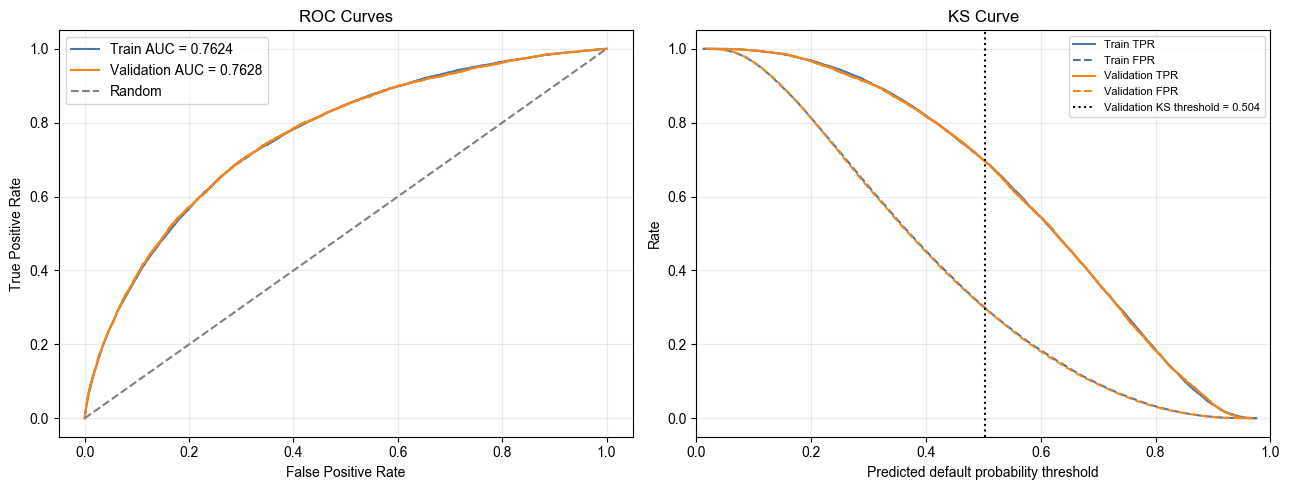

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curves
axes[0].plot(fpr_tr, tpr_tr, label=f'Train AUC = {auc_train:.4f}', color='#4C78A8')
axes[0].plot(fpr_vl, tpr_vl, label=f'Validation AUC = {auc_val:.4f}', color='#F58518')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
axes[0].set_title('ROC Curves')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()
axes[0].grid(alpha=0.25)

# KS curves
axes[1].plot(thr_tr, tpr_tr, label='Train TPR', color='#4C78A8')
axes[1].plot(thr_tr, fpr_tr, label='Train FPR', color='#4C78A8', linestyle='--')
axes[1].plot(thr_vl, tpr_vl, label='Validation TPR', color='#F58518')
axes[1].plot(thr_vl, fpr_vl, label='Validation FPR', color='#F58518', linestyle='--')
axes[1].axvline(ks_thr_val, color='black', linestyle=':', label=f'Validation KS threshold = {ks_thr_val:.3f}')
axes[1].set_title('KS Curve')
axes[1].set_xlabel('Predicted default probability threshold')
axes[1].set_ylabel('Rate')
axes[1].set_xlim(0, 1)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

**Business interpretation.** The validation AUC and KS are close to the training results, suggesting that the scorecard has stable ranking power rather than only memorising the training data. This is important because Notebook 03 uses the model output to allocate lending capital; unstable predictions would lead to unstable prescriptive decisions.

## 12. Save All PKL Files

In [13]:
# Generate the master customer score table and save all key objects
train_result = train_woe_final[['SK_ID_CURR', 'TARGET']].copy()
train_result['score'] = np.round(train_scores).astype(int)
train_result['数据集'] = '训练集'

val_result = val_woe_final[['SK_ID_CURR', 'TARGET']].copy()
val_result['score'] = np.round(val_scores).astype(int)
val_result['数据集'] = '验证集'

full_result = pd.concat([train_result, val_result], ignore_index=True)
full_result['是否违约'] = full_result['TARGET'].map({0: '否', 1: '是'})
full_result = full_result[['SK_ID_CURR', 'score', '是否违约', '数据集']]

print(f'Master customer score table shape: {full_result.shape}')
print(f'\nScore statistics:')
print(f'  All customers: mean={full_result["score"].mean():.1f}, '
      f'minimum={full_result["score"].min()}, maximum={full_result["score"].max()}')
print(f'  Defaulting customers (yes): mean={full_result.loc[full_result["是否违约"]=="是","score"].mean():.1f}')
print(f'  Non-defaulting customers (no): mean={full_result.loc[full_result["是否违约"]=="否","score"].mean():.1f}')

os.makedirs(PKL_OUT_DIR, exist_ok=True)
scorecard_path = os.path.join(PKL_OUT_DIR, 'customer_scorecard.csv')
full_result.to_csv(scorecard_path, index=False, encoding='utf-8-sig')

save_dict = {
    'binners.pkl': binners,
    'woe_map.pkl': woe_map,
    'selected_features.pkl': selected_features,
    'scaler.pkl': scaler,
    'lr_model.pkl': lr,
    'train_woe_final.pkl': train_woe_final,
    'val_woe_final.pkl': val_woe_final,
    'customer_scorecard.pkl': full_result,
}

print(f'\nSaving Notebook 02 output files to: {PKL_OUT_DIR}')
print('-' * 60)
print(f'  customer_scorecard.csv              ({os.path.getsize(scorecard_path) / 1024 / 1024:.1f} MB)')
for fname, obj in save_dict.items():
    fpath = os.path.join(PKL_OUT_DIR, fname)
    joblib.dump(obj, fpath)
    size_mb = os.path.getsize(fpath) / 1024 / 1024
    print(f'  {fname:<35} ({size_mb:.1f} MB)')
print('-' * 60)
print('Notebook 02 outputs have been saved and can be loaded directly by 03_Prescriptive_Analytics_LP.ipynb.')


Master customer score table shape: (307511, 4)

Score statistics:
  All customers: mean=630.0, minimum=334, maximum=914


  Defaulting customers (yes): Mean=564.4
  Non-defaulting customers (no): Mean=635.8



Saving Notebook 02 output files to: /Users/fanhongquan/Desktop/project 1 assignment 2/dataset/processed/03
------------------------------------------------------------
  customer_scorecard.csv              (7.3 MB)
  binners.pkl                         (0.6 MB)
  woe_map.pkl                         (0.0 MB)
  selected_features.pkl               (0.0 MB)
  scaler.pkl                          (0.0 MB)
  lr_model.pkl                        (0.0 MB)
  train_woe_final.pkl                 (40.6 MB)
  val_woe_final.pkl                   (10.1 MB)
  customer_scorecard.pkl              (4.7 MB)
------------------------------------------------------------
Notebook 02 outputs have been saved and can be loaded directly by 03_Prescriptive_Analytics_LP.ipynb.


## 13. Score Distribution and Interpretability Checks

A scorecard model should satisfy a basic business expectation: defaulting customers should have a lower average score than non-defaulting customers. The following analysis compares the score distributions of defaulting and non-defaulting customers and reports the logistic regression coefficient directions for the final 20 model features.

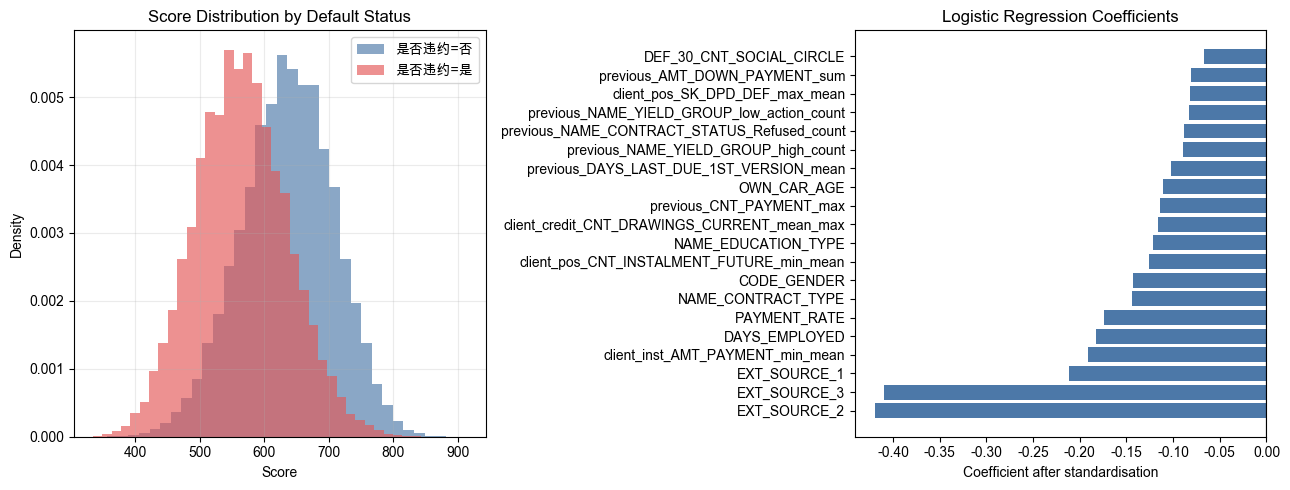

Average score of defaulting customers: 564.41
Average score of non-defaulting customers: 635.76


,feature,coefficient
1,EXT_SOURCE_2,-0.419791
0,EXT_SOURCE_3,-0.409640
2,EXT_SOURCE_1,-0.211306
4,client_inst_AMT_PAYMENT_min_mean,-0.191671
6,DAYS_EMPLOYED,-0.182163
3,PAYMENT_RATE,-0.173769
7,NAME_CONTRACT_TYPE,-0.143644
11,CODE_GENDER,-0.142753
10,client_pos_CNT_INSTALMENT_FUTURE_min_mean,-0.125771
9,NAME_EDUCATION_TYPE,-0.121142


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for label, color in [('否', '#4C78A8'), ('是', '#E45756')]:
    subset = full_result.loc[full_result['是否违约'] == label, 'score']
    axes[0].hist(subset, bins=35, alpha=0.65, label=f'Default status={label}', color=color, density=True)
axes[0].set_title('Score Distribution by Default Status')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(alpha=0.25)

coef_df = pd.DataFrame({
    'feature': selected_features,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient')
axes[1].barh(coef_df['feature'], coef_df['coefficient'], color=np.where(coef_df['coefficient'] >= 0, '#E45756', '#4C78A8'))
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Logistic Regression Coefficients')
axes[1].set_xlabel('Coefficient after standardisation')

plt.tight_layout()
plt.show()

print('Average score of defaulting customers:', round(full_result.loc[full_result['是否违约'] == '是', 'score'].mean(), 2))
print('Average score of non-defaulting customers:', round(full_result.loc[full_result['是否违约'] == '否', 'score'].mean(), 2))
display(coef_df)

**Model interpretation.** A lower score indicates higher estimated default risk. The separation between default and non-default score distributions supports the business use of the scorecard as a risk-ranking tool. The coefficient table also helps explain which WOE-transformed variables drive the model prediction, improving transparency for business stakeholders.